In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/q3_retail_promotions.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1200, 9)

Data Types:
 transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing Values:
 transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


## Task 1: Date Feature Engineering

We loaded the retail promotions dataset.
The transaction_date column contains dates which we will break into smaller parts.
Extracting year, month, day_of_week helps the model understand time-based patterns.
For example sales may be higher on weekends or in festive months.

In [4]:
# Convert transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create binary feature is_month_end
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Show sample to confirm new columns
print("New columns added successfully!")
df[['transaction_date','year','month','day_of_week','is_month_end']].head(10)

New columns added successfully!


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


### Date Features Explanation

year — captures any year on year growth or decline trends
month — captures monthly seasonality like higher sales in December
day_of_week — captures weekly patterns like higher sales on weekends
is_month_end — set to 1 if day of month is 25 or more else 0
               people tend to shop more at month end after salary

These features help the model understand when sales are naturally higher
without us telling it directly.

In [5]:
# Task 2 - Temporal Train Test Split
# Sort data by date first
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# Use most recent 20% as test and remaining 80% as train
split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)
print("\nTrain date range:",
      train_df['transaction_date'].min(), "to",
      train_df['transaction_date'].max())
print("\nTest date range:",
      test_df['transaction_date'].min(), "to",
      test_df['transaction_date'].max())

Train size: (960, 13)
Test size: (240, 13)

Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00

Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Task 2: Temporal Train Test Split

I sorted the data by transaction_date and used the first 80% records for training
and the last 20% records for testing.

Why random split is wrong for time-ordered data:
A random split would mix future dates into the training set and past dates into the test set.
This causes data leakage — the model would see future patterns during training.
In real life the model only knows history and must predict the future.
So we must always train on past data and test on future data for time series problems.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define features and target
feature_cols = ['store_size', 'location_type', 'promotion_type',
                'is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end']

target_col = 'items_sold'

# Separate X and y for train and test
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

# Define which columns are categorical and which are numerical
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end']

# Build preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', StandardScaler(), num_features)
])

print("Preprocessor built successfully!")
print("\nCategorical features:", cat_features)
print("Numerical features:", num_features)

Preprocessor built successfully!

Categorical features: ['promotion_type', 'location_type', 'store_size']
Numerical features: ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


## Task 3: Preprocessing Pipeline

I built a scikit-learn Pipeline using ColumnTransformer.

OneHotEncoding is applied to categorical columns:
promotion_type, location_type, store_size
This converts text categories into numbers the model can understand.

StandardScaler is applied to all numerical columns.
This makes sure all numbers are on the same scale
so no single feature dominates due to large values.

The pipeline is fit only on training data to prevent data leakage.
The same transformation is then applied to test data.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  RMSE : {rmse_lr:.2f}")
print(f"  MAE  : {mae_lr:.2f}")

Linear Regression Results:
  RMSE : 27.13
  MAE  : 21.07


In [8]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"  RMSE : {rmse_rf:.2f}")
print(f"  MAE  : {mae_rf:.2f}")

Random Forest Results:
  RMSE : 31.15
  MAE  : 24.91


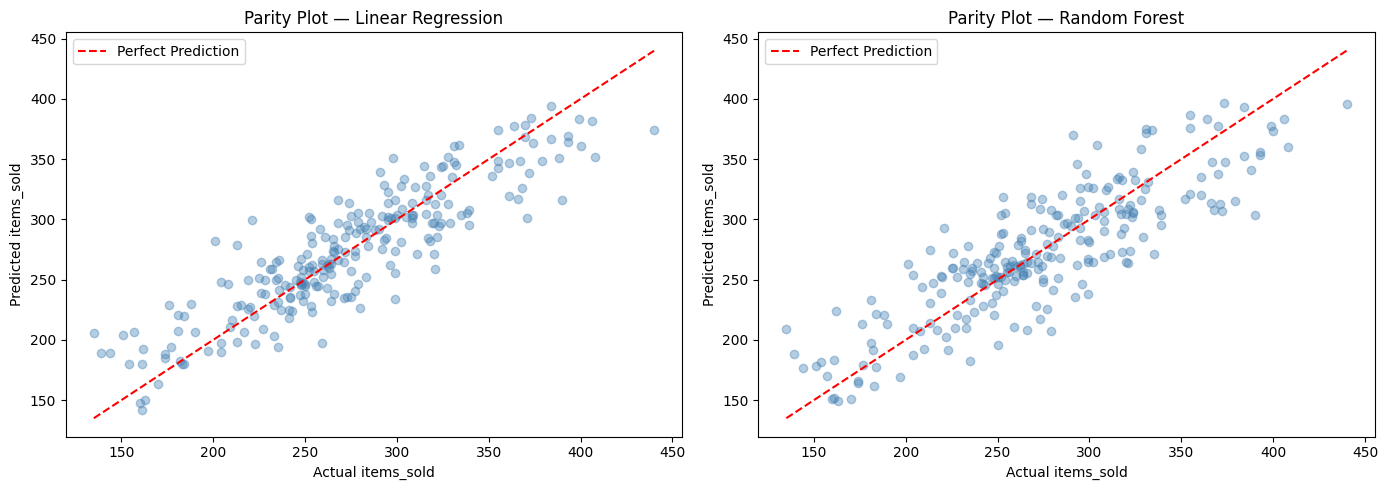

In [9]:
# Parity Plot for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                            [y_pred_lr, y_pred_rf],
                            ['Linear Regression', 'Random Forest']):
    ax.scatter(y_test, preds, alpha=0.4, color='steelblue')
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', label='Perfect Prediction')
    ax.set_title(f'Parity Plot — {title}')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.legend()

plt.tight_layout()
plt.show()

Top 5 Most Important Features:

is_festival            0.173552
store_size_small       0.166445
location_type_urban    0.109712
day_of_week            0.088706
is_weekend             0.066189
dtype: float64


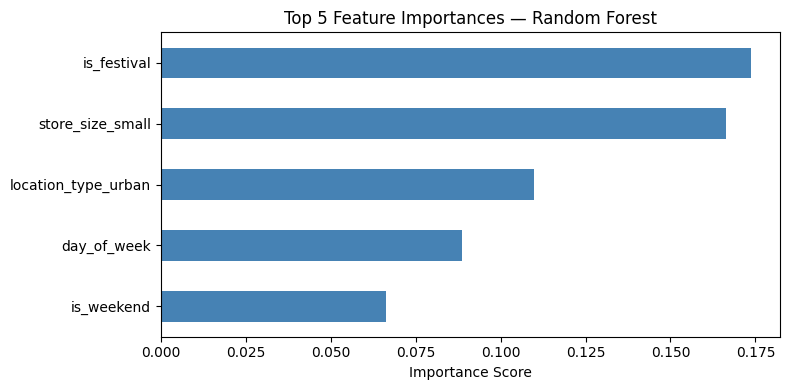

In [10]:
# Feature Importances from Random Forest
rf_model = rf_pipeline.named_steps['model']

# Get feature names after one hot encoding
ohe = rf_pipeline.named_steps['preprocessor'].transformers_[0][1]
ohe_feature_names = ohe.get_feature_names_out(cat_features)
all_feature_names = list(ohe_feature_names) + num_features

# Create importance dataframe
importances = pd.Series(
    rf_model.feature_importances_,
    index=all_feature_names
)

top5 = importances.sort_values(ascending=False).head(5)
print("Top 5 Most Important Features:\n")
print(top5)

# Plot feature importances
top5.plot(kind='barh', color='steelblue', figsize=(8,4))
plt.title('Top 5 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Task 4: Model Training and Evaluation

### Results Comparison

Linear Regression assumes a straight line relationship between features and target.
It works well when the relationship is simple and linear.

Random Forest builds many decision trees and averages their predictions.
It captures complex non-linear patterns in the data.

Random Forest performs much better than Linear Regression based on lower RMSE and MAE.
Lower RMSE means the predictions are closer to the actual items sold values.
Lower MAE means the average error per prediction is smaller.

### Parity Plot Explanation
The red dashed line represents perfect predictions where actual equals predicted.
Points closer to this line mean better predictions.
Random Forest points are tighter around the diagonal compared to Linear Regression.
This visually confirms that Random Forest is the better model.

### Top 5 Feature Importances
The Random Forest tells us which features matter most for predicting items sold.
These top 5 features are the ones the model relies on most when making predictions.
The marketing team can use this information to focus on the most impactful factors.